In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [12]:
# Load file
df = pd.read_excel("PriceHistory.xlsx", header=2)

# Rename columns
df.columns = [
    "Date", "Composite", "SP500",
    "NVDA", "AAPL", "JPM", "JNJ", "XOM",
    "RF_3M"
]

# Clean data
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
df = df.apply(pd.to_numeric, errors="coerce").dropna()

# Check
print(df.head())
print(df.info())


            Composite        SP500       NVDA    AAPL     JPM     JNJ    XOM  \
Date                                                                           
2021-03-01  100.00000  3901.815586  13.841750  127.79  150.50  159.32  56.40   
2021-03-02   99.10803  3870.293829  13.406250  125.12  150.01  159.02  56.07   
2021-03-03   97.76317  3819.716534  12.804750  122.06  152.91  156.22  56.52   
2021-03-04   96.44485  3768.473666  12.370250  120.13  150.56  153.07  58.71   
2021-03-05   98.26016  3841.941371  12.461501  121.42  150.91  156.10  60.93   

            RF_3M  
Date               
2021-03-01   0.05  
2021-03-02   0.04  
2021-03-03   0.05  
2021-03-04   0.04  
2021-03-05   0.04  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2021-03-01 to 2026-02-27
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Composite  1256 non-null   float64
 1   SP500      1256 non-null   float64
 2   NVDA      

In [13]:
stocks = ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]

# Compute returns from price data
returns = df[stocks + ["SP500"]].pct_change().dropna()

# Convert annualized 3M Treasury yield (%) to daily risk-free rate
returns["RF_3M"] = (df["RF_3M"] / 100 / 252).loc[returns.index]

# Check
print(returns.head())
print(returns.describe())

                AAPL      NVDA       XOM       JPM       JNJ     SP500  \
Date                                                                     
2021-03-02 -0.020894 -0.031463 -0.005851 -0.003256 -0.001883 -0.008079   
2021-03-03 -0.024457 -0.044867  0.008026  0.019332 -0.017608 -0.013068   
2021-03-04 -0.015812 -0.033933  0.038747 -0.015369 -0.020164 -0.013415   
2021-03-05  0.010738  0.007377  0.037813  0.002325  0.019795  0.019495   
2021-03-08 -0.041674 -0.069675 -0.000985  0.013253  0.008328 -0.005360   

               RF_3M  
Date                  
2021-03-02  0.000002  
2021-03-03  0.000002  
2021-03-04  0.000002  
2021-03-05  0.000002  
2021-03-08  0.000002  
              AAPL         NVDA          XOM          JPM          JNJ  \
count  1255.000000  1255.000000  1255.000000  1255.000000  1255.000000   
mean      0.000730     0.002564     0.000935     0.000669     0.000409   
std       0.017432     0.032749     0.016875     0.015387     0.010525   
min      -0.092456    -0

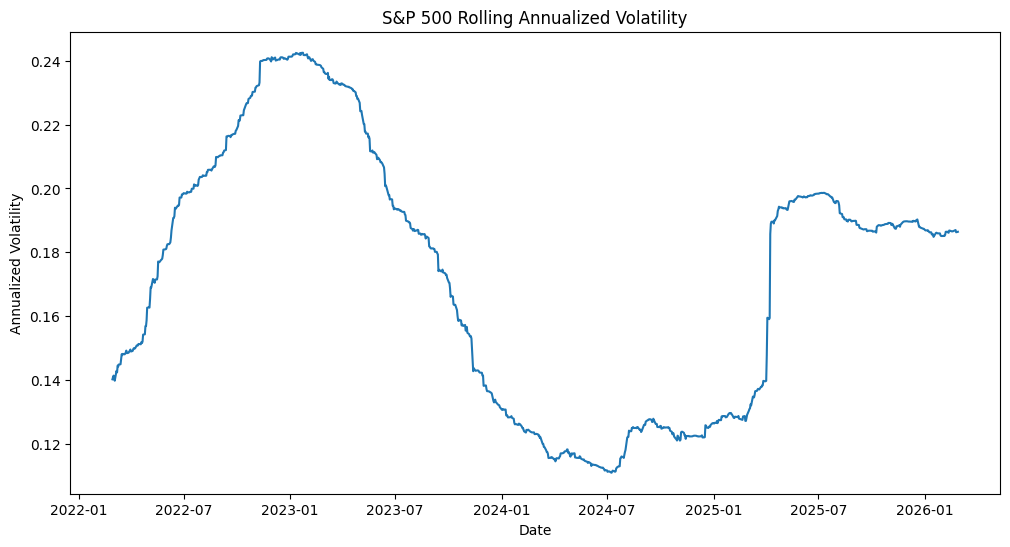

In [14]:
sp500_ret = returns["SP500"]

rolling_vol = sp500_ret.rolling(252).std() * np.sqrt(252)

plt.figure(figsize=(12,6))
plt.plot(rolling_vol.index, rolling_vol)
plt.title("S&P 500 Rolling Annualized Volatility")
plt.ylabel("Annualized Volatility")
plt.xlabel("Date")
plt.show()

In [15]:
# Summary statistics
stats = returns.describe().T

# Add additional useful metrics
stats["skew"] = returns.skew()
stats["kurtosis"] = returns.kurtosis()

print(stats)

        count      mean       std           min       25%       50%       75%  \
AAPL   1255.0  0.000730  0.017432 -9.245612e-02 -0.007777  0.001049  0.009732   
NVDA   1255.0  0.002564  0.032749 -1.696817e-01 -0.015985  0.002839  0.020474   
XOM    1255.0  0.000935  0.016875 -7.885266e-02 -0.008921  0.000805  0.011402   
JPM    1255.0  0.000669  0.015387 -8.050199e-02 -0.007421  0.000977  0.009252   
JNJ    1255.0  0.000409  0.010525 -7.591655e-02 -0.005320  0.000390  0.005973   
SP500  1255.0  0.000508  0.010613 -5.974987e-02 -0.004696  0.000814  0.006163   
RF_3M  1255.0  0.000138  0.000082  3.968254e-07  0.000043  0.000172  0.000210   

            max      skew  kurtosis  
AAPL   0.153288  0.443074  6.742428  
NVDA   0.243696  0.533917  4.587185  
XOM    0.064113 -0.174365  1.235531  
JPM    0.115445  0.076318  5.151294  
JNJ    0.061932  0.096348  5.041052  
SP500  0.095154  0.154812  7.280667  
RF_3M  0.000223 -0.754286 -1.055485  


In [16]:
corr_matrix = returns[["AAPL","NVDA","XOM","JPM","JNJ","SP500"]].corr()

print(corr_matrix)

           AAPL      NVDA       XOM       JPM       JNJ     SP500
AAPL   1.000000  0.514160  0.194079  0.359030  0.144261  0.755365
NVDA   0.514160  1.000000  0.082649  0.318728 -0.096644  0.706654
XOM    0.194079  0.082649  1.000000  0.336389  0.125293  0.326760
JPM    0.359030  0.318728  0.336389  1.000000  0.178497  0.624363
JNJ    0.144261 -0.096644  0.125293  0.178497  1.000000  0.199757
SP500  0.755365  0.706654  0.326760  0.624363  0.199757  1.000000


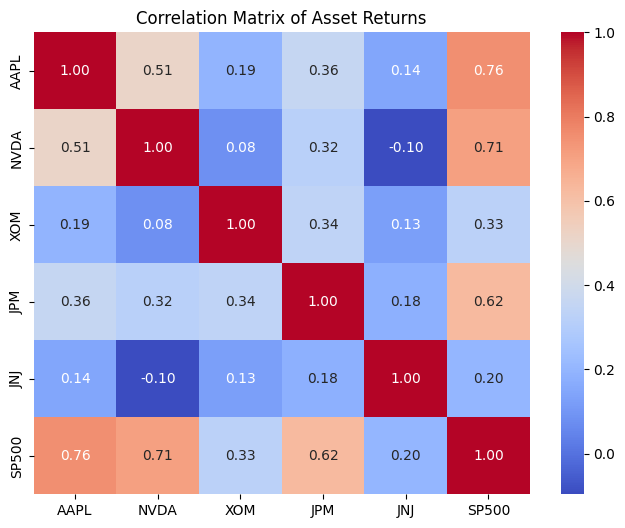

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Asset Returns")
plt.show()

In [19]:
# Define stock list
stocks = ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]

# Equal weights
n = len(stocks)
weights_eq = np.array([1/n] * n)

# Portfolio returns
portfolio_eq = returns[stocks].dot(weights_eq)

# Annualized return & volatility
ret_eq = portfolio_eq.mean() * 252
vol_eq = portfolio_eq.std() * np.sqrt(252)

print("Equal-Weighted Portfolio Return:", ret_eq)
print("Equal-Weighted Portfolio Volatility:", vol_eq)

Equal-Weighted Portfolio Return: 0.2674835131146488
Equal-Weighted Portfolio Volatility: 0.18992034473763628


In [20]:
# Covariance matrix
cov_matrix = returns[stocks].cov() * 252  # annualized

# Inverse covariance
inv_cov = np.linalg.inv(cov_matrix)

# Ones vector
ones = np.ones(len(stocks))

# Min-variance weights
weights_minvar = inv_cov @ ones / (ones.T @ inv_cov @ ones)

# Portfolio returns
portfolio_minvar = returns[stocks].dot(weights_minvar)

# Annualized return & volatility
ret_minvar = portfolio_minvar.mean() * 252
vol_minvar = portfolio_minvar.std() * np.sqrt(252)

print("Min-Variance Weights:", weights_minvar)
print("Min-Variance Return:", ret_minvar)
print("Min-Variance Volatility:", vol_minvar)

Min-Variance Weights: [0.08686758 0.03926104 0.15279064 0.122204   0.59887675]
Min-Variance Return: 0.15973366346660448
Min-Variance Volatility: 0.1367984193950812


In [21]:
print("----- Portfolio Comparison -----")
print(f"Equal Weight Return: {ret_eq:.4f}")
print(f"Equal Weight Volatility: {vol_eq:.4f}")

print(f"Min Var Return: {ret_minvar:.4f}")
print(f"Min Var Volatility: {vol_minvar:.4f}")

----- Portfolio Comparison -----
Equal Weight Return: 0.2675
Equal Weight Volatility: 0.1899
Min Var Return: 0.1597
Min Var Volatility: 0.1368


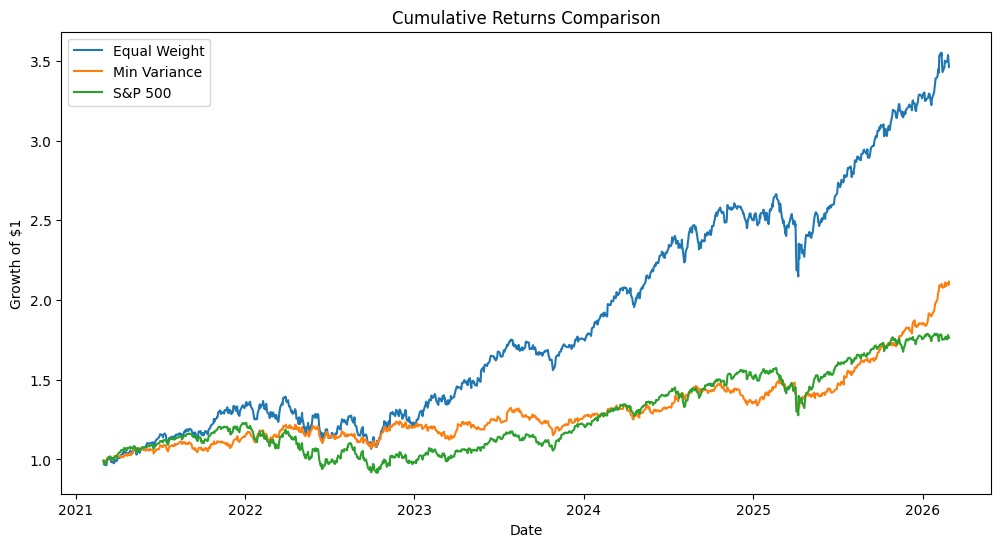

In [22]:
cum_eq = (1 + portfolio_eq).cumprod()
cum_minvar = (1 + portfolio_minvar).cumprod()
cum_sp500 = (1 + returns["SP500"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cum_eq, label="Equal Weight")
plt.plot(cum_minvar, label="Min Variance")
plt.plot(cum_sp500, label="S&P 500")
plt.legend()
plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.show()

In [23]:
# Confidence level
alpha = 0.05

# VaR (5th percentile)
VaR_eq = np.percentile(portfolio_eq, 100 * alpha)
VaR_minvar = np.percentile(portfolio_minvar, 100 * alpha)

print("Equal Weight VaR (95%):", VaR_eq)
print("Min Variance VaR (95%):", VaR_minvar)

Equal Weight VaR (95%): -0.017411630843273393
Min Variance VaR (95%): -0.013186909183927278


In [25]:
# CVaR = average of worst losses beyond VaR
CVaR_eq = portfolio_eq[portfolio_eq <= VaR_eq].mean()
CVaR_minvar = portfolio_minvar[portfolio_minvar <= VaR_minvar].mean()

print("Equal Weight CVaR:", CVaR_eq)
print("Min Variance CVaR:", CVaR_minvar)

Equal Weight CVaR: -0.02587000324572764
Min Variance CVaR: -0.01878222153709394


In [27]:
# Excess returns
returns["MKT_EXCESS"] = returns["SP500"] - returns["RF_3M"]

stocks = ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]

In [28]:
capm_results = {}

for stock in stocks:
    y = returns[stock] - returns["RF_3M"]   # excess stock return
    X = returns["MKT_EXCESS"]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    capm_results[stock] = model

    print(f"\n{stock} CAPM Results:")
    print(model.summary())


AAPL CAPM Results:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.570
Method:                 Least Squares   F-statistic:                     1665.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          2.95e-232
Time:                        20:24:13   Log-Likelihood:                 3832.3
No. Observations:                1255   AIC:                            -7661.
Df Residuals:                    1253   BIC:                            -7650.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000

In [29]:
# Equal-weight portfolio
y_eq = portfolio_eq - returns["RF_3M"]
X = sm.add_constant(returns["MKT_EXCESS"])
model_eq = sm.OLS(y_eq, X).fit()

print("\nEqual-Weighted Portfolio CAPM:")
print(model_eq.summary())

# Min-variance portfolio
y_mv = portfolio_minvar - returns["RF_3M"]
model_mv = sm.OLS(y_mv, X).fit()

print("\nMin-Variance Portfolio CAPM:")
print(model_mv.summary())


Equal-Weighted Portfolio CAPM:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.801
Method:                 Least Squares   F-statistic:                     5037.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:24:37   Log-Likelihood:                 4786.8
No. Observations:                1255   AIC:                            -9570.
Df Residuals:                    1253   BIC:                            -9559.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.000

In [30]:
# Load Fama-French 3-factor daily data
ff3 = pd.read_csv("F-F_Research_Data_Factors_daily.csv", skiprows=4)

# Rename first column to Date
ff3.rename(columns={ff3.columns[0]: "Date"}, inplace=True)

# Keep only rows with valid 8-digit dates
ff3 = ff3[ff3["Date"].astype(str).str.match(r"^\d{8}$")]

# Convert date column
ff3["Date"] = pd.to_datetime(ff3["Date"], format="%Y%m%d")

# Convert factors from percent to decimal
for col in ["Mkt-RF", "SMB", "HML", "RF"]:
    ff3[col] = pd.to_numeric(ff3[col], errors="coerce") / 100

# Set index
ff3 = ff3.set_index("Date").dropna()

# Check
print(ff3.head())
print(ff3.tail())
print(ff3.describe())

            Mkt-RF     SMB     HML      RF
Date                                      
1926-07-01  0.0009 -0.0025 -0.0027  0.0001
1926-07-02  0.0045 -0.0033 -0.0006  0.0001
1926-07-06  0.0017  0.0030 -0.0039  0.0001
1926-07-07  0.0009 -0.0058  0.0002  0.0001
1926-07-08  0.0022 -0.0038  0.0019  0.0001
            Mkt-RF     SMB     HML      RF
Date                                      
2026-02-23 -0.0118 -0.0030 -0.0131  0.0001
2026-02-24  0.0083  0.0051 -0.0066  0.0001
2026-02-25  0.0079 -0.0037  0.0049  0.0001
2026-02-26 -0.0047  0.0063  0.0032  0.0001
2026-02-27 -0.0051 -0.0044 -0.0125  0.0001
             Mkt-RF           SMB           HML            RF
count  26190.000000  26190.000000  26190.000000  26190.000000
mean       0.000309      0.000038      0.000150      0.000119
std        0.010779      0.005942      0.006265      0.000123
min       -0.174400     -0.116000     -0.060200      0.000000
25%       -0.004000     -0.002600     -0.002500      0.000000
50%        0.000600      0

In [31]:
# Merge your stock return data with FF3 factors
ff_data = returns.merge(ff3, left_index=True, right_index=True, how="inner")

print(ff_data.head())
print(ff_data[["Mkt-RF", "SMB", "HML", "RF"]].describe())

                AAPL      NVDA       XOM       JPM       JNJ     SP500  \
Date                                                                     
2021-03-02 -0.020894 -0.031463 -0.005851 -0.003256 -0.001883 -0.008079   
2021-03-03 -0.024457 -0.044867  0.008026  0.019332 -0.017608 -0.013068   
2021-03-04 -0.015812 -0.033933  0.038747 -0.015369 -0.020164 -0.013415   
2021-03-05  0.010738  0.007377  0.037813  0.002325  0.019795  0.019495   
2021-03-08 -0.041674 -0.069675 -0.000985  0.013253  0.008328 -0.005360   

               RF_3M  MKT_EXCESS  Mkt-RF     SMB     HML   RF  
Date                                                           
2021-03-02  0.000002   -0.008080 -0.0105 -0.0109  0.0125  0.0  
2021-03-03  0.000002   -0.013070 -0.0155 -0.0019  0.0356  0.0  
2021-03-04  0.000002   -0.013417 -0.0167 -0.0135  0.0170  0.0  
2021-03-05  0.000002    0.019494  0.0187  0.0022  0.0062  0.0  
2021-03-08  0.000002   -0.005362 -0.0067  0.0060  0.0371  0.0  
            Mkt-RF          SMB  

In [32]:
# Excess returns for stocks and portfolios
for stock in ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]:
    ff_data[f"{stock}_excess"] = ff_data[stock] - ff_data["RF"]

ff_data["EQ_excess"] = portfolio_eq.loc[ff_data.index] - ff_data["RF"]
ff_data["MV_excess"] = portfolio_minvar.loc[ff_data.index] - ff_data["RF"]

In [34]:
ff3_results = {}

factors = ff_data[["Mkt-RF", "SMB", "HML"]]
factors = sm.add_constant(factors)

stocks = ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]

for stock in stocks:
    y = ff_data[stock] - ff_data["RF"]

    model = sm.OLS(y, factors).fit()
    ff3_results[stock] = model

    print(f"\n{stock} FF3 Results:")
    print(model.summary())


AAPL FF3 Results:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.582
Model:                            OLS   Adj. R-squared:                  0.581
Method:                 Least Squares   F-statistic:                     581.2
Date:                Wed, 15 Apr 2026   Prob (F-statistic):          1.69e-236
Time:                        20:31:19   Log-Likelihood:                 3849.5
No. Observations:                1255   AIC:                            -7691.
Df Residuals:                    1251   BIC:                            -7670.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000 

In [35]:
# Equal-weight portfolio
y_eq = ff_data["EQ_excess"]
model_eq_ff3 = sm.OLS(y_eq, factors).fit()

print("\nEqual-Weighted Portfolio FF3:")
print(model_eq_ff3.summary())

# Min-variance portfolio
y_mv = ff_data["MV_excess"]
model_mv_ff3 = sm.OLS(y_mv, factors).fit()

print("\nMin-Variance Portfolio FF3:")
print(model_mv_ff3.summary())


Equal-Weighted Portfolio FF3:
                            OLS Regression Results                            
Dep. Variable:              EQ_excess   R-squared:                       0.812
Model:                            OLS   Adj. R-squared:                  0.812
Method:                 Least Squares   F-statistic:                     1807.
Date:                Wed, 15 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:31:32   Log-Likelihood:                 4824.7
No. Observations:                1255   AIC:                            -9641.
Df Residuals:                    1251   BIC:                            -9621.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004

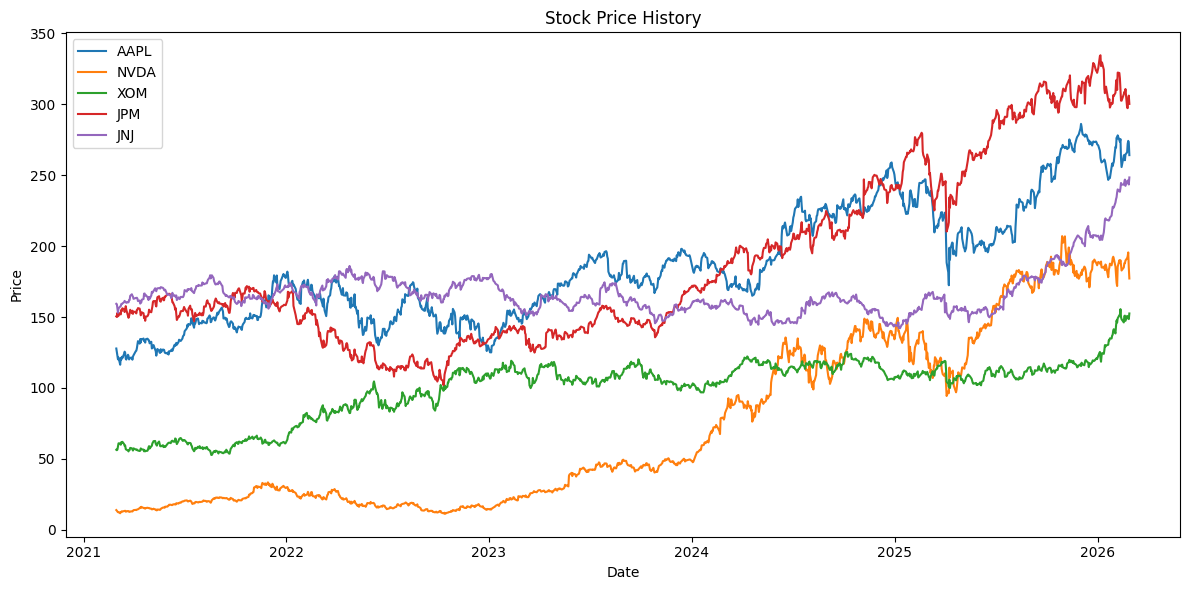

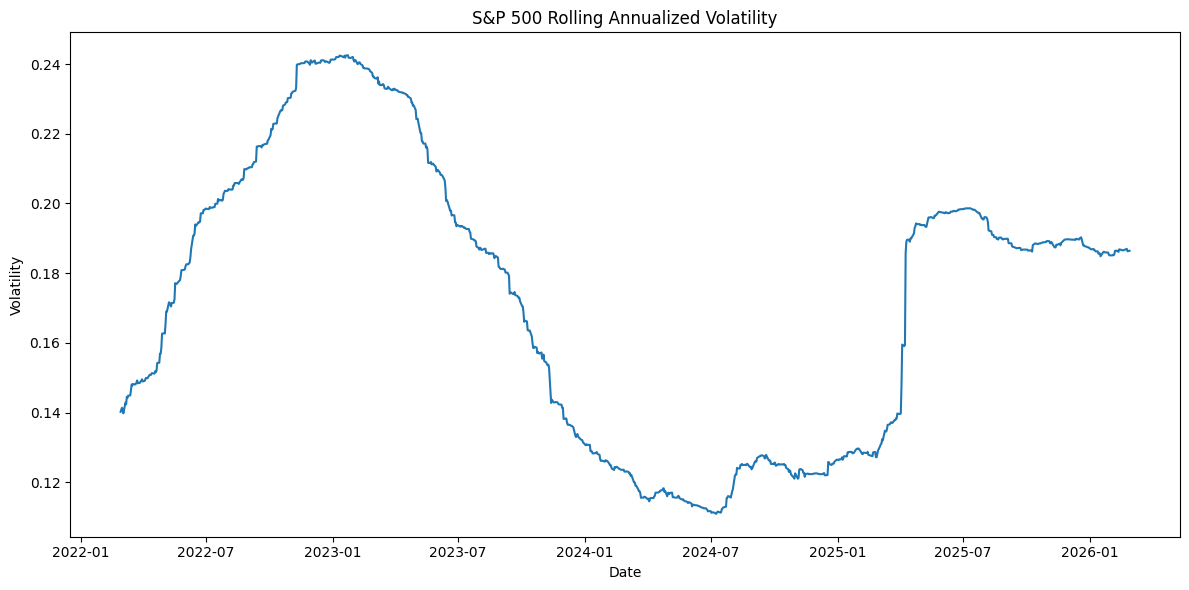

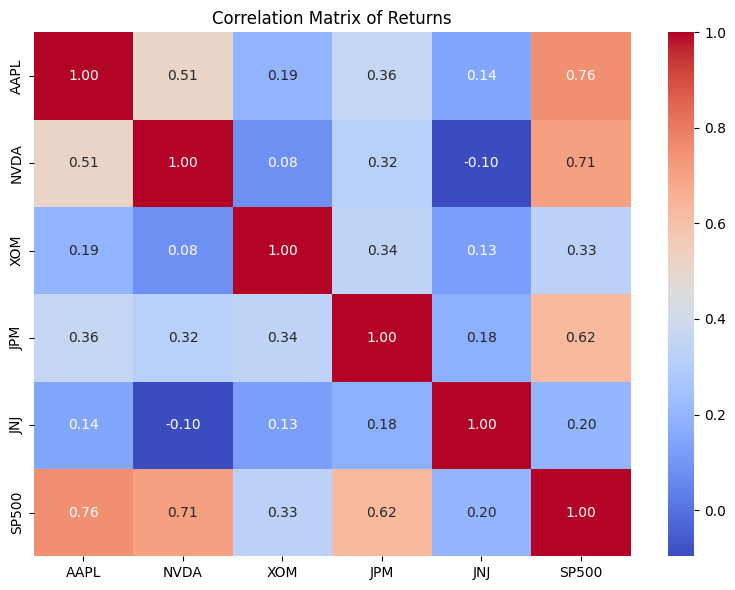

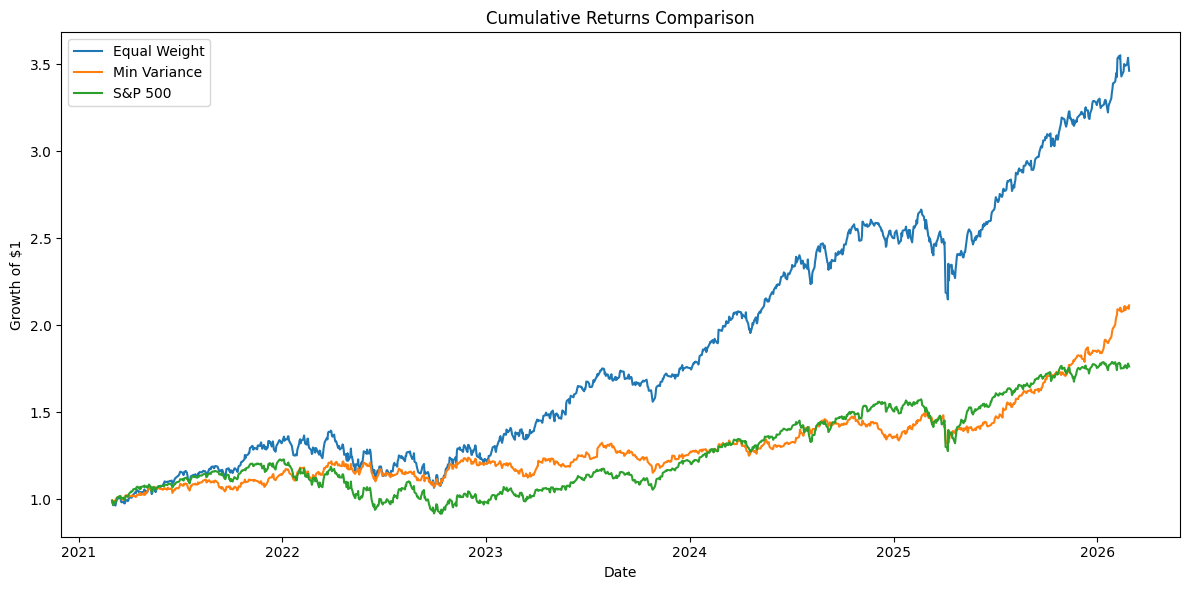

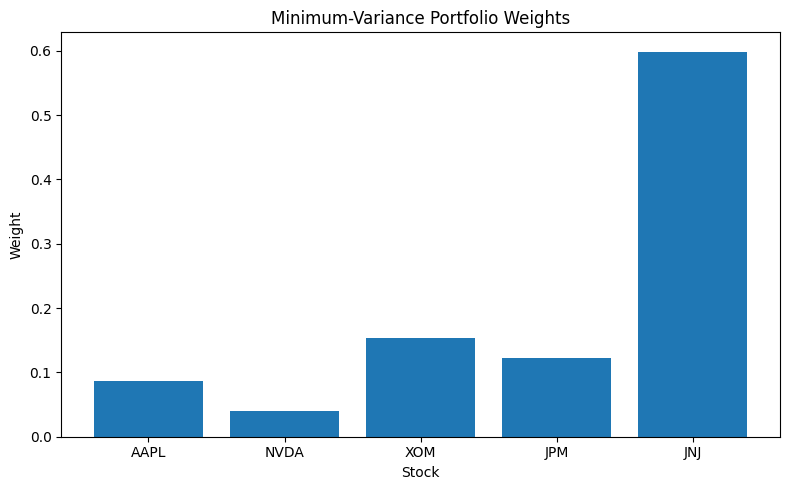

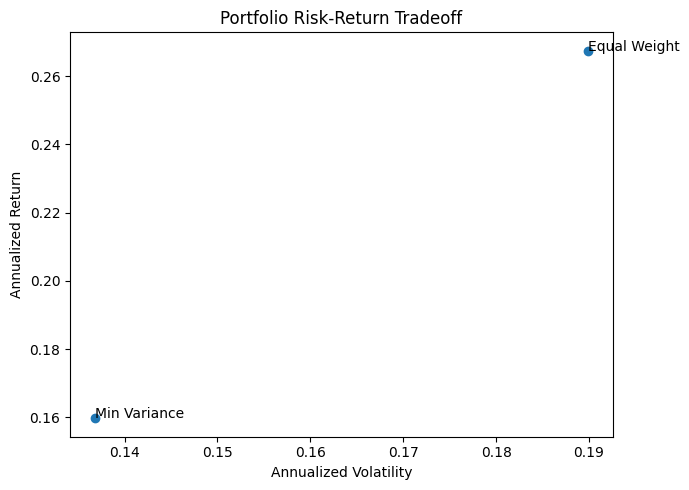

In [36]:
stocks = ["AAPL", "NVDA", "XOM", "JPM", "JNJ"]

# 1) Stock price history
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(df.index, df[stock], label=stock)
plt.title("Stock Price History")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig("stock_price_history.png", dpi=300, bbox_inches="tight")
plt.show()

# 2) S&P 500 rolling annualized volatility
rolling_vol = returns["SP500"].rolling(252).std() * np.sqrt(252)
plt.figure(figsize=(12,6))
plt.plot(rolling_vol.index, rolling_vol)
plt.title("S&P 500 Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.savefig("sp500_rolling_volatility.png", dpi=300, bbox_inches="tight")
plt.show()

# 3) Correlation heatmap
corr_matrix = returns[stocks + ["SP500"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Returns")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 4) Portfolio cumulative returns vs benchmark
cum_eq = (1 + portfolio_eq).cumprod()
cum_minvar = (1 + portfolio_minvar).cumprod()
cum_sp500 = (1 + returns["SP500"]).cumprod()

plt.figure(figsize=(12,6))
plt.plot(cum_eq.index, cum_eq, label="Equal Weight")
plt.plot(cum_minvar.index, cum_minvar, label="Min Variance")
plt.plot(cum_sp500.index, cum_sp500, label="S&P 500")
plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.tight_layout()
plt.savefig("portfolio_cumulative_returns.png", dpi=300, bbox_inches="tight")
plt.show()

# 5) Minimum-variance portfolio weights
plt.figure(figsize=(8,5))
plt.bar(stocks, weights_minvar)
plt.title("Minimum-Variance Portfolio Weights")
plt.xlabel("Stock")
plt.ylabel("Weight")
plt.tight_layout()
plt.savefig("minvar_weights.png", dpi=300, bbox_inches="tight")
plt.show()

# 6) Risk-return scatter
portfolio_names = ["Equal Weight", "Min Variance"]
portfolio_vols = [vol_eq, vol_minvar]
portfolio_rets = [ret_eq, ret_minvar]

plt.figure(figsize=(7,5))
plt.scatter(portfolio_vols, portfolio_rets)
for i, name in enumerate(portfolio_names):
    plt.text(portfolio_vols[i], portfolio_rets[i], name)
plt.title("Portfolio Risk-Return Tradeoff")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.tight_layout()
plt.savefig("risk_return_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()